# Causal Feature Selection — a mini-tutorial

Suppose you want to **predict one variable** in a multivariate time series — a
KPI, a patient outcome, a sensor. In practice almost everyone reaches for a
**correlational** feature selector (Lasso, mutual information, top-correlation):
fast and often accurate, but it happily keeps variables that *predict* the target
without *causing* it. Such models can be brittle when the data-generating regime
shifts, and — crucially — **misleading the moment you act on them**.

If instead you want the target's **actual causes**, you *could* run full causal
discovery and read the target's neighbourhood off the graph — but that is
**O(d²)** and computes the entire graph when you needed one target's corner of it.
`select_features` gets you just that corner — the target's causes — in **O(d)**.

This notebook is a guided tour of *why* causal features are worth it and *how* to
use them.

**Three things you'll get, and why each matters:**

1. **Speed.** Single-target discovery is O(d) vs O(d²) for a full graph — we'll
   *see* the curves diverge.
2. **Causal, not merely correlational, features.** The headline. Correlational
   selectors pick variables that predict but don't cause; those models look great
   until you **act** on them. If you intervene — `do(X)` — on a spurious feature,
   nothing happens. We demonstrate this the way a policy or treatment decision
   would put a model to the test.
3. **A ready-to-fit design matrix.** From features to a trained predictor in three
   lines.

**Notebook contents**

1. Setup & a 30-second quick start
2. The problem, and a map of the three backends
3. Recovering a *known* truth
4. `fastpc` vs real `cdnots`
5. The O(d) speed win
6. The full Markov blanket (children & spouses)
7. **Interpretability & intervention — why *causal* features matter**
8. Building & validating a predictor (parsimony, robustness, nuisance)
9. When to use which backend — and the limitations
10. Summary & next steps

## 1. Setup

We import the library, fix seeds for reproducibility, and define a small set of
**plotting helpers** used throughout so every figure shares one visual language.
The single most important convention is a fixed **role → colour** map — every
feature the tool returns has a *role* (parent, child, spouse, self, …) and that
role keeps the same colour in every graph and bar chart below.

In [1]:
import sys
sys.path.insert(0, "..")

import time
import warnings

# Silence third-party chatter (tqdm's ipywidgets notice fires on import, so this
# must come before the causalts import below).
warnings.filterwarnings("ignore", message=".*IProgress.*")
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from causalts.feature_selection import select_features
from causalts.synthetic_data.synthetic_datasets import ex2, lorenz96

# --- one visual language (colours validated for colour-blind safety) ----------
SURFACE, INK, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
ROLE_COLORS = {
    "parent": "#2a78d6",          # blue   — a direct cause
    "child": "#eb6834",           # orange — the target causes it
    "spouse": "#1baf7a",          # aqua   — co-parent of a shared child
    "self": "#eda100",            # yellow — autoregressive (own past)
    "undirected": "#e87ba4",      # magenta— lag-0 adjacency, direction unresolved
    "nonstationarity": "#4a3aa7", # violet — C -> target (time trend)
}
TARGET_COLOR = INK

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "figure.dpi": 110,
})


def features_df(r):
    "Render a FeatureSelectionResult's features as a tidy DataFrame."
    rows = [
        {"variable": f.variable, "lag": f.lag, "role": f.role,
         "score": (round(f.score, 4) if f.score is not None else None)}
        for f in r.features
    ]
    return pd.DataFrame(rows)


from causalts.plotting._core import plot_graph

_GRAPH_ROLES = set(ROLE_COLORS)


def fs_to_graph(r):
    "Assemble a compact (d, d, L+1) graph from a result's features for plot_graph."
    feats = [f for f in r.features if f.role in _GRAPH_ROLES]
    names = [r.target]
    for f in feats:
        if f.variable not in names:
            names.append(f.variable)
    idx = {n: i for i, n in enumerate(names)}
    t = idx[r.target]
    g = np.zeros((len(names), len(names), r.max_lag + 1))
    # A shared child may be an oriented child OR a lag-0 undirected adjacency.
    shared_children = [(f.variable, f.lag) for f in feats
                       if f.role in ("child", "undirected")]
    for f in feats:
        s = idx[f.variable]
        if f.role in ("parent", "nonstationarity"):
            g[s, t, f.lag] = 1                      # incoming cause
        elif f.role == "child":
            g[t, s, f.lag] = 1                      # outgoing effect
        elif f.role == "undirected":
            g[s, t, 0] = 1; g[t, s, 0] = 1          # lag-0, direction unresolved
        elif f.role == "self":
            g[t, t, f.lag] = 1                      # autoregressive
        elif f.role == "spouse":                    # co-parent of a shared child
            for cv, cl in shared_children:
                if cl + f.lag <= r.max_lag:
                    g[s, idx[cv], cl + f.lag] = 1
    return g, names


def plot_fs_graph(r, ax=None, title=None, figsize=(4.4, 3.8), node_pos=None, node_size=0.32):
    "Render a result's neighbourhood with the library's own plot_graph (neato)."
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    g, names = fs_to_graph(r)
    plot_graph(g, var_names=names, target_node=r.target, fig_ax=(ax.figure, ax),
               show_colorbar=False, node_size=node_size, arrow_linewidth=2.4,
               show_autodependency_lags=True, label_fontsize=9, node_label_size=11,
               node_layout="neato", node_pos=node_pos,
               target_in_color=ROLE_COLORS["parent"],
               target_out_color=ROLE_COLORS["child"])
    if title:
        ax.set_title(title, fontsize=10)
    return ax


def positions_by_name(node_pos_out, names):
    "Reindex a returned {'x','y'} position dict to a new variable order by name."
    lut = {n: (node_pos_out["x"][i], node_pos_out["y"][i]) for i, n in enumerate(names)}
    return lut


def node_pos_for(order, lut):
    "Build a plot_graph node_pos dict for `order` from a name->(x,y) lookup."
    return {"x": np.array([lut[n][0] for n in order]),
            "y": np.array([lut[n][1] for n in order])}


def plot_scores(r, ax=None, title="Feature strength (ranking only)"):
    "Compact horizontal bar chart of feature scores, coloured by role."
    if ax is None:
        _, ax = plt.subplots(figsize=(4.2, 2.6))
    feats = [f for f in r.features if f.score is not None and f.role in ROLE_COLORS]
    feats = sorted(feats, key=lambda f: f.score)
    labels = [f"{f.variable} (t-{f.lag})" for f in feats]
    ax.barh(labels, [f.score for f in feats],
            color=[ROLE_COLORS[f.role] for f in feats], height=0.62)
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("score")
    ax.set_title(title, fontsize=10)
    return ax


print("setup complete — role colours:", list(ROLE_COLORS))

setup complete — role colours: ['parent', 'child', 'spouse', 'self', 'undirected', 'nonstationarity']


### A 30-second quick start — the whole loop

Before any theory, here is the entire workflow end to end: **select the causal
features → build the design matrix → fit a model**. We load `ex2` (a 6-variable
linear system) and predict `X3` from its causes alone.

In [2]:
from sklearn.linear_model import LinearRegression

data = ex2(seed=42, T=1000)
df, max_lag = data["df"], data["max_lag"]

r = select_features(df, "X3", max_lag=max_lag, algo="cedar")   # 1. causal features
X = r.to_design_matrix()                                       # 2. model-ready columns
y = df["X3"].iloc[max_lag:]
model = LinearRegression().fit(X, y)                           # 3. fit
print(f"selected {X.shape[1]} features -> R^2 = {model.score(X, y):.3f}")
features_df(r)

selected 4 features -> R^2 = 0.622


,variable,lag,role,score
0,X4,1,parent,0.6469
1,X0,2,parent,0.4337
2,X3,1,self,0.1256


> **Takeaway:** three lines take you from raw data to a fitted predictor.
> `select_features` returns the target's causes as typed
> `(variable, lag, role, score)` records; `to_design_matrix()` turns them into
> lagged columns. The rest of the notebook unpacks *why* those features — and not
> the most *correlated* ones — are what you want.

## 2. The problem, and three backends

Full causal discovery returns the entire graph over `d` variables — **O(d²)**
conditional-independence work. But to *predict* one target you only need its
**direct causes** (its parents), or at most its **Markov blanket** (parents +
children + the children's other parents). Finding just that is **O(d)**, because
you only ever test the target *as an effect*.

`select_features` offers three backends. Pick with `algo=`:

| backend | cost | what it does | use it when… |
|---|---|---|---|
| **`cedar`** | O(d) | pairwise single-target search; assumes AR(1) self-history | you want the fast default and roughly linear/pairwise dependence |
| **`fastpc`** | O(d) | local PC-around-the-target *skeleton* — a fast **approximation** of CDNOTS adjacency (no orientation / Meek / MCI) | you want speed and are OK with lag-0 edges left `undirected` |
| **`cdnots`** | O(d²) | the **real** CDNOTS run once and sliced to the target — fully oriented | you want faithful orientation (parent vs child) and can pay full cost |

Two things worth internalising before we go on:

- **Temporal precedence orients lagged edges for free.** A cause at `lag ≥ 1`
  precedes its effect, so it is unambiguously a **parent**. Only *contemporaneous*
  (`lag 0`) edges are direction-ambiguous — `fastpc` reports those as
  **`undirected`**; real `cdnots` tries to orient them.
- **Discovery ≠ prediction.** `result.features` reports what discovery *found*.
  Which self-history lags actually become model inputs is a separate, predictive
  decision made in `to_design_matrix(include_self=, self_threshold=)`.

## 3. Recovering a *known* truth

The most convincing test of a discovery tool is to plant a known answer and watch
it come back. `ex2` is a linear VAR system with `max_lag = 3` and known equations
(with $c=\sqrt{2}$, i.i.d. Gaussian noise per equation):

$$
\begin{aligned}
X_0(t) &= 0.5c\,X_0(t{-}1) \\
X_1(t) &= 0.5\,X_0(t{-}2) \\
X_2(t) &= -0.4\,X_0(t{-}3) \\
X_3(t) &= 0.25c\,X_3(t{-}1) \;-\; 0.5\,X_0(t{-}2) \;+\; 0.45c\,X_4(t{-}1) \\
X_4(t) &= 0.25c\,X_4(t{-}1) \;-\; 0.5c\,X_3(t{-}1) \\
X_5(t) &= 0.65\,X_5(t{-}1) \;-\; 0.1\,X_2(t{-}1) \;-\; 0.55\,X_4(t{-}2)
\end{aligned}
$$

Read off the equation for $X_3$: its causes are $X_0(t{-}2)$, $X_4(t{-}1)$, and
its own past $X_3(t{-}1)$. That is exactly what `select_features` should recover.

In [3]:
r = select_features(df, "X3", max_lag=max_lag, algo="cedar")
features_df(r)

,variable,lag,role,score
0,X4,1,parent,0.6469
1,X0,2,parent,0.4337
2,X3,1,self,0.1256


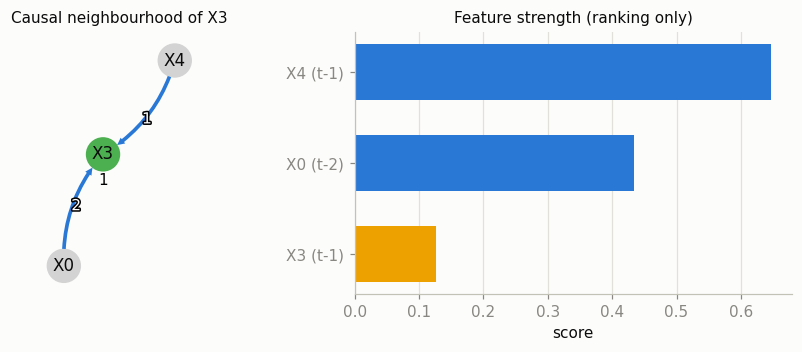

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.6, 3.3),
                             gridspec_kw={"width_ratios": [1.1, 1]})
plot_fs_graph(r, ax=a1, title="Causal neighbourhood of X3")
plot_scores(r, ax=a2, title="Feature strength (ranking only)")
plt.tight_layout()
plt.show()

The graph is rendered by the library's own `plot_graph` (via a target-node
highlight): **blue arrows point *into* the target — its causes (parents)**; the
**green** node is the target; a self-dependency shows as a lag label on the node.

> **Takeaway:** the two **parents** ($X_0$ at lag 2, $X_4$ at lag 1) and the lag-1
> **self** term match the equation for $X_3$ exactly — nothing spurious was added.
>
> A note on `score`: it **ranks** features, it does not **filter** them — every
> returned feature is selected regardless of score. Cross-variable scores are the
> CI test's statistic; the self score is a partial distance-correlation.

## 4. `fastpc` vs real `cdnots`

`fastpc` is the fast skeleton; `cdnots` is the real, fully-oriented algorithm.
They agree on the lagged parents (temporal precedence pins those), but differ on
contemporaneous edges: `fastpc` leaves lag-0 adjacencies **`undirected`**, while
real `cdnots` orients them. Here they agree on `X3`; the difference shows up on
targets with contemporaneous neighbours.

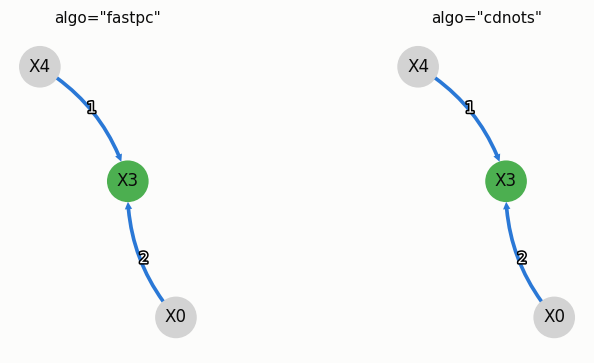

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.4))
for ax, algo in zip(axes, ["fastpc", "cdnots"]):
    ra = select_features(df, "X3", max_lag=max_lag, algo=algo)
    plot_fs_graph(ra, ax=ax, title=f'algo="{algo}"')
plt.tight_layout()
plt.show()

> **Takeaway:** for a target whose causes are all lagged, `fastpc` and
> `cdnots` return the same parents — so you can pay O(d) for `fastpc` and only
> reach for O(d²) `cdnots` when contemporaneous orientation matters.

## 5. The O(d) speed win

Now the performance claim, measured rather than asserted. We sweep the number of
variables `d` on `lorenz96` (a ring-structured system) and time **full CDNOTS**
(the whole graph, O(d²)) against **`fastpc`** on a single target (O(d)). On
log–log axes, O(d) is a flatter line than O(d²).

In [6]:
from causalts.cdnots.phase3_utils import run_cdnots
from causalts.ci_tests.parcorr_gpu import ParCorrGPU

ds = [10, 20, 40, 80]
t_full, t_single = [], []
for N in ds:
    ldata = lorenz96(N=N, T=600)
    ldf, lL = ldata["df"], ldata["max_lag"]

    t0 = time.time()
    run_cdnots(ldf, ParCorrGPU(np.zeros((2, 2))), num_lags=lL, verbose=False)
    t_full.append(time.time() - t0)

    t0 = time.time()
    select_features(ldf, ldf.columns[0], max_lag=lL, algo="fastpc")
    t_single.append(time.time() - t0)
    print(f"d={N:3d}  full={t_full[-1]:7.3f}s  fastpc={t_single[-1]:6.3f}s  "
          f"speedup={t_full[-1]/max(t_single[-1],1e-6):5.1f}x")

d= 10  full=  0.067s  fastpc= 0.003s  speedup= 20.8x


d= 20  full=  0.193s  fastpc= 0.005s  speedup= 41.6x


d= 40  full=  0.716s  fastpc= 0.007s  speedup= 96.1x


d= 80  full=  2.789s  fastpc= 0.012s  speedup=232.3x


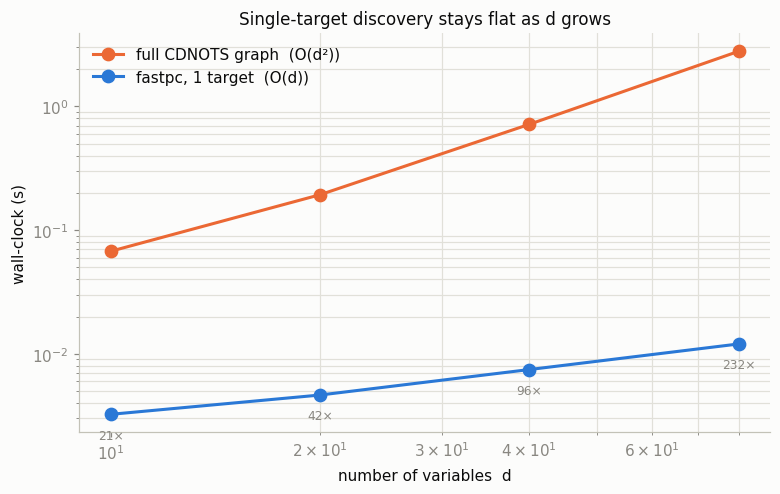

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(ds, t_full, "-o", color=ROLE_COLORS["child"], lw=2, ms=8,
        label="full CDNOTS graph  (O(d²))")
ax.plot(ds, t_single, "-o", color=ROLE_COLORS["parent"], lw=2, ms=8,
        label="fastpc, 1 target  (O(d))")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("number of variables  d"); ax.set_ylabel("wall-clock (s)")
ax.set_title("Single-target discovery stays flat as d grows")
for x, yf, ys in zip(ds, t_full, t_single):
    ax.annotate(f"{yf/max(ys,1e-6):.0f}×", (x, ys), textcoords="offset points",
                xytext=(0, -16), ha="center", fontsize=8, color=MUTED)
ax.legend(frameon=False)
ax.grid(which="both", axis="both")
plt.tight_layout()
plt.show()

> **Takeaway:** the full-graph curve climbs with `d` while single-target
> stays nearly flat — the speedup *widens* as the problem grows (the `×` labels
> are the ratio at each `d`). If you only need one target, don't pay for the whole
> graph.

## 6. The full Markov blanket

The default returns **parents** — the genuinely O(d) path. The theoretically
*optimal* predictive set, though, is the **Markov blanket**: parents **+
children + the children's other parents (spouses)**. Given the Markov blanket,
the target is independent of everything else — you cannot do better for
prediction.

Recovering it costs O(d²) (you must check every other variable to see if the
target is one of *its* causes), so it is opt-in via `markov_blanket=True`.

**Why spouses are subtle.** A spouse is a *co-parent* of a shared child, connected
to the target only through a **collider** (v-structure). We build a small system
with a known spouse to make it concrete:

- `X0`, `X1` are independent noise.
- `X2(t) = 0.8·X0(t) + 0.8·X1(t-1) + noise` — so `X0(t) → X2(t)` and
  `X1(t-1) → X2(t)`.

`X0` and `X1` are **marginally independent** but become dependent once you
condition on their shared child `X2`. With `target = X0`, `X1` is a spouse.

In [8]:
rng = np.random.default_rng(0)
T = 2000
x0 = rng.standard_normal(T)
x1 = rng.standard_normal(T)
x2 = np.zeros(T)
for t in range(1, T):
    x2[t] = 0.8 * x0[t] + 0.8 * x1[t - 1] + 0.1 * rng.standard_normal()
collider_df = pd.DataFrame({"X0": x0, "X1": x1, "X2": x2})

r_pc = select_features(collider_df, "X0", max_lag=2, algo="cedar",
                       include_lag0=True, markov_blanket=False)
r_mb = select_features(collider_df, "X0", max_lag=2, algo="cedar",
                       include_lag0=True, markov_blanket=True)
print("PC set (default):", [(f.variable, f.lag, f.role) for f in r_pc.features])
print("Markov blanket   :", [(f.variable, f.lag, f.role) for f in r_mb.features])

PC set (default): [('X2', 0, 'undirected'), ('X0', 1, 'self')]
Markov blanket   : [('X1', 1, 'spouse'), ('X2', 0, 'undirected'), ('X0', 1, 'self')]


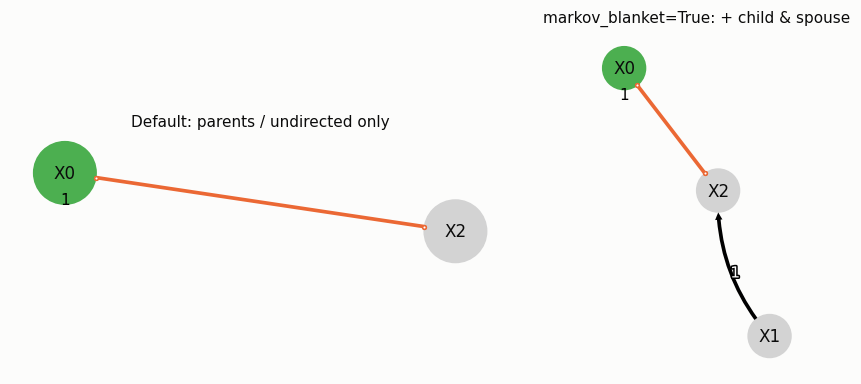

In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.8, 3.6))
plot_fs_graph(r_pc, ax=a1, title="Default: parents / undirected only")
plot_fs_graph(r_mb, ax=a2, title="markov_blanket=True: + child & spouse")
plt.tight_layout()
plt.show()

`X1` (aqua **spouse**) appears only with `markov_blanket=True`; the default
correctly does **not** claim it as a cause of `X0`. With `algo="cdnots"` the
blanket is read straight off the full oriented graph instead of by re-running per
variable — no extra searches needed.

FeatureSelectionResult(target='X4', algo='cdnots', features=4 [child=2, parent=1, spouse=1], markov_blanket=True)


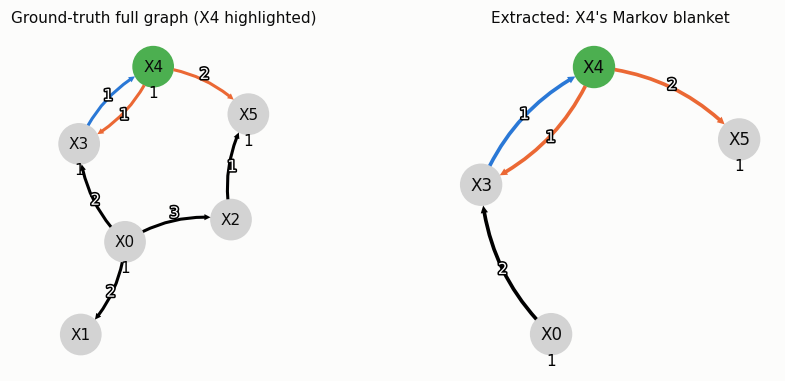

,variable,lag,role,score
0,X3,1,parent,0.4821
1,X3,1,child,0.1882
2,X5,2,child,0.1465
3,X0,1,spouse,0.0147


In [10]:
r_cd = select_features(df, "X4", max_lag=max_lag, algo="cdnots",
                       markov_blanket=True)
print(r_cd)

# Extract *just* X4's Markov blanket from the full oriented graph and plot that
# subgraph next to the ground-truth FULL graph, so you can see the whole system
# vs. the corner select_features returned.
mb_vars = ["X4"] + [v for v in r_cd.variables if v != "X4"]
full_names = list(r_cd.result.var_names)
ids = [full_names.index(v) for v in mb_vars]
mb_graph = r_cd.result.cg_tig[np.ix_(ids, ids, range(r_cd.result.cg_tig.shape[2]))]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.6, 4.0))
# Lay out the ground-truth graph, keep its node positions, and reuse them for the
# extracted MB so shared nodes sit in exactly the same place across both panels.
_, _, gt_pos = plot_graph(
    data["ground_truth"], var_names=list(df.columns), target_node="X4",
    fig_ax=(fig, a1), show_colorbar=False, node_size=0.3, arrow_linewidth=2.0,
    show_autodependency_lags=True, label_fontsize=9, node_label_size=10,
    node_layout="neato", return_pos=True,
    target_in_color=ROLE_COLORS["parent"], target_out_color=ROLE_COLORS["child"])
a1.set_title("Ground-truth full graph (X4 highlighted)", fontsize=10)

lut = positions_by_name(gt_pos, list(df.columns))
plot_graph(mb_graph, var_names=mb_vars, target_node="X4", fig_ax=(fig, a2),
           show_colorbar=False, node_size=0.2, arrow_linewidth=2.4,
           show_autodependency_lags=True, label_fontsize=9, node_label_size=11,
           node_pos=node_pos_for(mb_vars, lut),
           target_in_color=ROLE_COLORS["parent"], target_out_color=ROLE_COLORS["child"])
a2.set_title("Extracted: X4's Markov blanket", fontsize=10)
plt.show()
features_df(r_cd)

## 7. Why *causal* features matter: interpretability & intervention

This is the section that separates causal feature selection from every
correlational selector. A model that merely *predicts* well can still be
**useless — or dangerous — for decisions**, because it may lean on features that
are correlated with the target but do not cause it. The moment you *act* on such a
feature (`do(X)`), the association evaporates.

Think of a treatment `A` that is correlated with recovery `Y` only because
healthier patients (a confounder `W`) both receive `A` and recover — `A` does not
*work*. A correlational model will happily use `A` and predict recovery beautifully
on historical data. Prescribe `A` to raise `Y`, and nothing happens.

We build exactly that structure as a time series. `W` is an **observed**
confounder, `A` tracks `W` but has **no arrow to `Y`**, and `C` is the true cause:

$$
W(t)=0.6\,W(t{-}1)+\varepsilon,\quad
A(t)=W(t)+\varepsilon,\quad
C(t)=\varepsilon,\quad
Y(t)=1.2\,C(t{-}1)+0.9\,W(t{-}1)+\varepsilon
$$

Because `W` is observed, `select_features` can **adjust for it** — the key to
telling a real cause from a confounded association.

In [11]:
def simulate_confounded(T=1600, seed=0, aw=1.0, do=None):
    "Confounded time-series SCM. `do` additively shifts a variable's realised value."
    do = do or {}
    rng = np.random.default_rng(seed)
    W = np.zeros(T); A = np.zeros(T); C = np.zeros(T); Y = np.zeros(T)
    eW = rng.standard_normal(T) * 0.5
    eA = rng.standard_normal(T) * 0.5
    eC = rng.standard_normal(T) * 1.0
    eY = rng.standard_normal(T) * 0.5
    for t in range(2, T):
        W[t] = 0.6 * W[t - 1] + eW[t]
        C[t] = eC[t]
        A[t] = aw * W[t] + eA[t]                 # A tracks W, but is NOT a cause of Y
        if "W" in do: W[t] += do["W"]
        if "A" in do: A[t] += do["A"]
        if "C" in do: C[t] += do["C"]
        Y[t] = 1.2 * C[t - 1] + 0.9 * W[t - 1] + eY[t]
    return pd.DataFrame({"W": W, "A": A, "C": C, "Y": Y})


cdf = simulate_confounded(seed=0)
print("Observational correlations with Y(t):")
for v in ["W", "A", "C"]:
    print(f"  corr(Y, {v}(t-1)) = {cdf[v].shift(1).corr(cdf['Y']): .3f}")
print("\nA is associated with Y (via the confounder W) — yet A does NOT cause Y.")

Observational correlations with Y(t):
  corr(Y, W(t-1)) =  0.362
  corr(Y, A(t-1)) =  0.276
  corr(Y, C(t-1)) =  0.841

A is associated with Y (via the confounder W) — yet A does NOT cause Y.


**Step 1 — what does causal feature selection return?** It identifies `Y`'s
parents and, crucially, **excludes `A`**: once you condition on the confounder
`W`, `A` carries no further information about `Y`.

select_features parents of Y : [('C', 1), ('W', 1)]
A among them?                : False


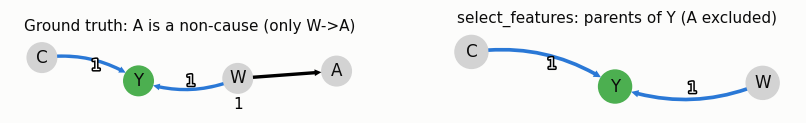

In [12]:
r_causal = select_features(cdf, "Y", max_lag=2, algo="cdnots")
parents = [(f.variable, f.lag) for f in r_causal.by_role("parent")]
print("select_features parents of Y :", parents)
print("A among them?                :", any(v == "A" for v, _ in parents))

# Ground-truth graph of the confounded SCM (vars W, A, C, Y; max_lag 2).
gt_names = ["W", "A", "C", "Y"]
gi = {n: k for k, n in enumerate(gt_names)}
gt_conf = np.zeros((4, 4, 3))
gt_conf[gi["W"], gi["W"], 1] = 1     # W autoregressive
gt_conf[gi["W"], gi["A"], 0] = 1     # W -> A   (A is a dead end: no arrow to Y)
gt_conf[gi["C"], gi["Y"], 1] = 1     # C -> Y
gt_conf[gi["W"], gi["Y"], 1] = 1     # W -> Y

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.2, 3.8))
_, _, conf_pos = plot_graph(
    gt_conf, var_names=gt_names, target_node="Y", fig_ax=(fig, a1),
    show_colorbar=False, node_size=0.2, arrow_linewidth=2.2,
    show_autodependency_lags=True, label_fontsize=9, node_label_size=11,
    node_layout="neato", return_pos=True,
    target_in_color=ROLE_COLORS["parent"], target_out_color=ROLE_COLORS["child"])
a1.set_title("Ground truth: A is a non-cause (only W->A)", fontsize=10)
# reuse ground-truth positions for the extracted parents graph
lut = positions_by_name(conf_pos, gt_names)
_, r_names = fs_to_graph(r_causal)
plot_fs_graph(r_causal, ax=a2, title="select_features: parents of Y (A excluded)",
              node_pos=node_pos_for(r_names, lut), node_size=0.15)
plt.show()

**Step 2 — does that change the answer to a decision?** To estimate the
effect of intervening on a variable, we regress `Y` on it while **adjusting for
`Y`'s other parents** (the set `select_features` just gave us). We compare:

- **unadjusted** estimate (what a correlational analysis sees), and
- **adjusted** estimate (controlling for the discovered parents — proper backdoor
  adjustment),

against the **true** interventional effect read from the SCM via `do(·)`.

do(A): true ΔY=+0.000 | unadjusted(corr)=+0.955 | adjusted(causal)=-0.013
do(C): true ΔY=+2.395 | unadjusted(corr)=+2.349 | adjusted(causal)=+2.405


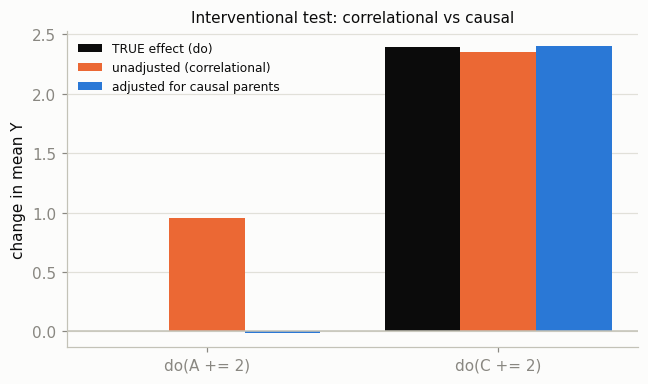

In [13]:
from sklearn.linear_model import LinearRegression


def ols_coef(frame, feats, target="Y"):
    X = pd.DataFrame({f"{v}_lag{l}": frame[v].shift(l) for (v, l) in feats})
    d = pd.concat([X, frame[target].rename("_y")], axis=1).dropna()
    m = LinearRegression().fit(d[X.columns], d["_y"])
    return dict(zip(X.columns, m.coef_))


delta = 2.0
rows = []
for var, lag in [("A", 1), ("C", 1)]:
    true = float((simulate_confounded(seed=0, do={var: delta})["Y"] - cdf["Y"]).mean())
    unadj = ols_coef(cdf, [(var, lag)])[f"{var}_lag{lag}"] * delta
    others = [(v, l) for (v, l) in parents if v != var]      # adjust for other parents
    adj = ols_coef(cdf, [(var, lag)] + others)[f"{var}_lag{lag}"] * delta
    rows.append((f"do({var} += {delta:g})", true, unadj, adj))
    print(f"do({var}): true ΔY={true:+.3f} | unadjusted(corr)={unadj:+.3f} "
          f"| adjusted(causal)={adj:+.3f}")

labels = [x[0] for x in rows]
xi = np.arange(len(labels)); w = 0.26
fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.bar(xi - w, [x[1] for x in rows], w, label="TRUE effect (do)", color=INK)
ax.bar(xi,     [x[2] for x in rows], w, label="unadjusted (correlational)", color=ROLE_COLORS["child"])
ax.bar(xi + w, [x[3] for x in rows], w, label="adjusted for causal parents", color=ROLE_COLORS["parent"])
ax.axhline(0, color=AXIS, lw=1)
ax.set_xticks(xi); ax.set_xticklabels(labels)
ax.set_ylabel("change in mean Y")
ax.set_title("Interventional test: correlational vs causal", fontsize=10)
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

> **Takeaway — the whole point of causal features.** Both `A` and `C` are
> associated with `Y`, so a correlational analysis flags both. But intervention
> tells them apart:
>
> - **`do(A)`** — the confounded non-cause. True effect is **zero**. The
>   *unadjusted* (correlational) estimate is large and **wrong**; adjusting for the
>   confounder `W` — which `select_features` identified as a parent — collapses it
>   to ~0. Prescribe `A` to move `Y` and nothing happens.
> - **`do(C)`** — the real cause. Both estimates recover the true effect (`C` is
>   not confounded), and `select_features` correctly kept it as the lever that
>   *does* work.
>
> Predictive association does not imply interventional validity. The value of
> causal feature selection is that it hands you the **correct adjustment set** — the
> parents — so effect estimates, and the decisions built on them, are valid.

## 8. Building & validating a predictor

Even for pure prediction, causal features buy you three concrete things. We show
each with a held-out comparison against a **kitchen-sink** model (every lag) and
**LassoCV** (given the same candidate pool).

### 8a. Parsimony — same accuracy, far fewer features

Each **bar's width is proportional to the number of features** the model uses (the
count is also printed above it), and its height is held-out RMSE. The narrow
causal bar reaches the same height as the wide kitchen-sink / Lasso bars — equal
accuracy at a fraction of the width. For reference, the true model has only a
handful of causal features (shown in the title).

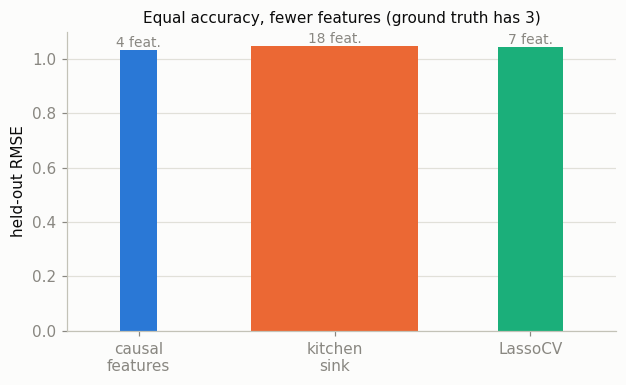

In [14]:
from sklearn.linear_model import LassoCV

target = "X3"
r_pred = select_features(df, target, max_lag=max_lag, algo="cedar")
design = r_pred.to_design_matrix(include_self=True, self_threshold=0.05)

y = df[target].iloc[max_lag:].to_numpy()
n_train = int(len(y) * 0.7)
all_cols = pd.DataFrame(
    {f"{c}_lag{l}": df[c].shift(l) for l in range(1, max_lag + 1) for c in df.columns}
).iloc[max_lag:]


def holdout_rmse(X):
    m = LinearRegression().fit(X.iloc[:n_train], y[:n_train])
    return float(np.sqrt(np.mean((m.predict(X.iloc[n_train:]) - y[n_train:]) ** 2)))


def holdout_rmse_lasso(X):
    m = LassoCV(cv=5, max_iter=5000).fit(X.iloc[:n_train], y[:n_train])
    p = m.predict(X.iloc[n_train:])
    return float(np.sqrt(np.mean((p - y[n_train:]) ** 2))), int(np.sum(np.abs(m.coef_) > 1e-8))


rmse_causal = holdout_rmse(design)
rmse_kitchen = holdout_rmse(all_cols)
rmse_lasso, n_lasso = holdout_rmse_lasso(all_cols)
methods = ["causal\nfeatures", "kitchen\nsink", "LassoCV"]
rmses = [rmse_causal, rmse_kitchen, rmse_lasso]
ncols = [design.shape[1], all_cols.shape[1], n_lasso]
colors = [ROLE_COLORS["parent"], ROLE_COLORS["child"], ROLE_COLORS["spouse"]]

# ground-truth number of causal features for X3 (incoming edges incl. self).
tj = list(df.columns).index("X3")
gt_n = int((data["ground_truth"][:, tj, :] == 1).sum())

xi = np.arange(len(methods))
widths = 0.85 * np.array(ncols) / max(ncols)   # bar thickness proportional to #features
fig, ax = plt.subplots(figsize=(5.8, 3.6))
bars = ax.bar(xi, rmses, width=widths, color=colors)
for x, b, nc in zip(xi, bars, ncols):
    ax.text(x, b.get_height(), f"{nc} feat.", ha="center", va="bottom",
            fontsize=9, color=MUTED)
ax.set_xticks(xi); ax.set_xticklabels(methods)
ax.set_ylabel("held-out RMSE")
ax.set_title(f"Equal accuracy, fewer features "
             f"(ground truth has {gt_n})", fontsize=10)
ax.grid(axis="x", visible=False)
ax.margins(x=0.12)
plt.tight_layout()
plt.show()

### 8b. Predicted vs actual on the held-out window

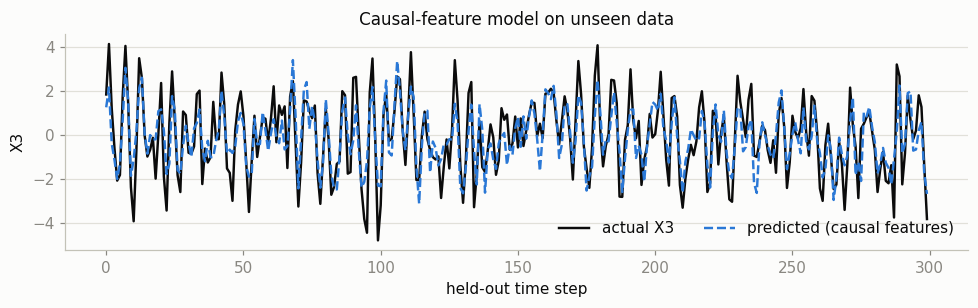

In [15]:
m = LinearRegression().fit(design.iloc[:n_train], y[:n_train])
pred = m.predict(design.iloc[n_train:])
idx = np.arange(len(y) - n_train)
fig, ax = plt.subplots(figsize=(9, 2.9))
ax.plot(idx, y[n_train:], color=INK, lw=1.6, label="actual X3")
ax.plot(idx, pred, color=ROLE_COLORS["parent"], lw=1.6, ls="--",
        label="predicted (causal features)")
ax.set_xlabel("held-out time step"); ax.set_ylabel("X3")
ax.set_title("Causal-feature model on unseen data")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

### 8c. Robustness — causal features survive distribution shift

Real datasets are full of variables correlated with the target but causally
irrelevant. We add 15 **nuisance** columns (each a noisy echo of a real variable)
and — this is the key — let their relationship to the data **flip sign at test
time** (a regime shift). A model that leaned on nuisance proxies breaks; a model
built on the true causes does not, because `ex2`'s causal mechanism is unchanged.

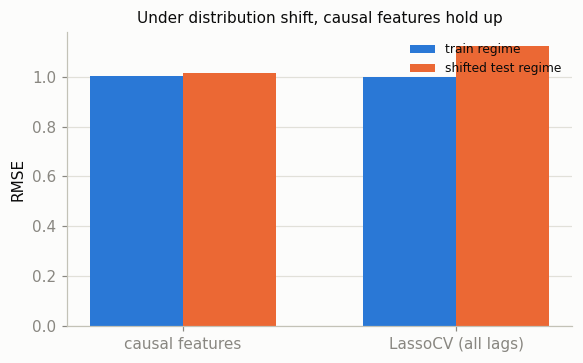

causal : train 1.002  test 1.012
lasso  : train 0.998  test 1.122


In [16]:
def add_nuisance(frame, k=15, seed=1, sign=1.0):
    "Append k nuisance columns, each a signed noisy echo of a random real column."
    rng = np.random.default_rng(seed)
    out = frame.copy()
    base = frame.to_numpy()
    for j in range(k):
        src = rng.integers(0, frame.shape[1])
        scale, noise = rng.uniform(0.8, 1.4), rng.uniform(0.8, 2.0)
        out[f"N{j}"] = sign * scale * base[:, src] + rng.standard_normal(len(frame)) * noise
    return out


train_noisy = add_nuisance(ex2(seed=42, T=1000)["df"], sign=+1.0)   # train regime
test_noisy = add_nuisance(ex2(seed=7, T=1000)["df"], sign=-1.0)     # nuisance links flip

r_rob = select_features(train_noisy, "X3", max_lag=max_lag, algo="cedar")
causal_feats3 = [(f.variable, f.lag) for f in r_rob.by_role("parent")] + [("X3", 1)]
all_feats3 = [(c, l) for l in range(1, max_lag + 1) for c in train_noisy.columns]


def _design(frame, feats):
    return pd.DataFrame({f"{v}_lag{l}": frame[v].shift(l) for (v, l) in feats})


def train_test_rmse(feats, use_lasso=False):
    Xtr, Xte = _design(train_noisy, feats), _design(test_noisy, feats)
    dtr = pd.concat([Xtr, train_noisy["X3"].rename("y")], axis=1).dropna()
    dte = pd.concat([Xte, test_noisy["X3"].rename("y")], axis=1).dropna()
    m = (LassoCV(cv=5, max_iter=5000) if use_lasso else LinearRegression())
    m.fit(dtr[Xtr.columns], dtr["y"])
    rt = np.sqrt(np.mean((m.predict(dtr[Xtr.columns]) - dtr["y"]) ** 2))
    re = np.sqrt(np.mean((m.predict(dte[Xte.columns]) - dte["y"]) ** 2))
    return float(rt), float(re)

c_tr, c_te = train_test_rmse(causal_feats3)
l_tr, l_te = train_test_rmse(all_feats3, use_lasso=True)

labels = ["causal features", "LassoCV (all lags)"]
xi = np.arange(2); w = 0.34
fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.bar(xi - w / 2, [c_tr, l_tr], w, label="train regime", color=ROLE_COLORS["parent"])
ax.bar(xi + w / 2, [c_te, l_te], w, label="shifted test regime", color=ROLE_COLORS["child"])
ax.set_xticks(xi); ax.set_xticklabels(labels)
ax.set_ylabel("RMSE")
ax.set_title("Under distribution shift, causal features hold up", fontsize=10)
ax.grid(axis="x", visible=False); ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()
print(f"causal : train {c_tr:.3f}  test {c_te:.3f}")
print(f"lasso  : train {l_tr:.3f}  test {l_te:.3f}")

### 8d. Nuisance variables — precision under noise

The same nuisance-augmented data also exposes a **precision** gap: asked for
`X3`'s predictors, causal selection ignores the nuisance columns while Lasso soaks
several up as proxies.

In [17]:
r_noisy = r_rob   # reuse the trained-regime selection from 8c
causal_cols = r_noisy.to_design_matrix(include_self=True).shape[1]

y2 = train_noisy["X3"].iloc[max_lag:].to_numpy()
ntr = int(len(y2) * 0.7)
allc = _design(train_noisy, all_feats3).iloc[max_lag:]
lasso = LassoCV(cv=5, max_iter=5000).fit(allc.iloc[:ntr], y2[:ntr])
lasso_cols = int(np.sum(np.abs(lasso.coef_) > 1e-8))
picked = [c for c, co in zip(allc.columns, lasso.coef_) if abs(co) > 1e-8]
lasso_nuisance = sum(c.startswith("N") for c in picked)
selected_nuisance = sum(f.variable.startswith("N") for f in r_noisy.features)

print(f"candidate features             : {allc.shape[1]}")
print(f"causal selection kept          : {causal_cols}  "
      f"(nuisance among them: {selected_nuisance})")
print(f"LassoCV kept                   : {lasso_cols}  "
      f"(nuisance among them: {lasso_nuisance})")
features_df(r_noisy)

candidate features             : 63
causal selection kept          : 4  (nuisance among them: 0)
LassoCV kept                   : 19  (nuisance among them: 15)


,variable,lag,role,score
0,X4,1,parent,0.6010
1,X0,2,parent,0.4166
2,X3,1,self,0.1256


> **Takeaway:** three wins for the price of one call — **parsimony** (equal
> accuracy, fewer features), **robustness** (survives distribution shift), and
> **precision** (ignores nuisance variables that trap correlational selectors).

## 9. When to use which backend — and the limitations

**Choosing a backend**

- **`cedar`** — the fast default; pairwise, assumes AR(1) self-history. Best first
  choice for O(d) selection.
- **`fastpc`** — O(d) skeleton; use when you want speed and can accept lag-0 edges
  reported as `undirected`. It is an *approximation* of CDNOTS adjacency.
- **`cdnots`** — the real, fully-oriented algorithm at O(d²). Use when parent-vs-
  child orientation of contemporaneous edges matters, or as the faithful reference.

**Limitations to keep honest about**

- **Latent confounders.** If an unobserved variable drives both a candidate and
  the target, its edge can be reported as a cause. Single-target selection cannot
  condition on what isn't measured — no method here handles hidden confounding.
- **Test choice = assumptions.** With the default linear `ParCorr`, a purely
  nonlinear cause can be missed. Pass a nonlinear `ci_test` (e.g. `KCIGPU`,
  `CMIknnGPU`) for nonlinear dependence — scores then use that test's conditional
  statistic too.
- **`markov_blanket=True` costs O(d²)** for `cedar`/`fastpc` (per-variable
  re-runs). For the blanket at scale, prefer `algo="cdnots"`, which reads it off
  the one graph it already computed.
- **Discovery vs. prediction of self-history.** `features` reflects what discovery
  surfaced; use `to_design_matrix(include_self=, self_threshold=)` to decide which
  self-lags actually enter the model.

Full quantitative validation against Lasso / correlation-top-k across several
datasets lives in `experiments/feature_selection/FINDINGS.md`.

## 10. Summary & next steps

- **`select_features(df, target, max_lag=…, algo=…)`** returns a single target's
  causal features in **O(d)** — no full O(d²) graph required.
- **Backends:** `cedar` (fast pairwise), `fastpc` (fast skeleton approximation),
  `cdnots` (real, fully oriented).
- **Roles:** `parent`, `child`, `spouse`, `self`, `undirected`, `nonstationarity`
  — a consistent, interpretable vocabulary.
- **`markov_blanket=True`** adds children + spouses (the theoretically optimal
  predictive set) at O(d²).
- **`to_design_matrix()`** turns the result into model-ready lagged columns.
- **Why causal beats correlational:** equal predictive accuracy, but only causal
  features give **valid interventional predictions**, **robustness to distribution
  shift**, and **immunity to nuisance variables**.

**Next steps**

- `experiments/feature_selection/FINDINGS.md` — full baseline benchmarks.
- `cedar_deep_dive.ipynb` — the single-target algorithm in depth.
- `effect_estimation.ipynb` — go from a discovered graph to estimated effects with
  DoWhy.